# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.

**Q2.** Load `Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The borough of NYC

1. Compute the average prices and scores by `Neighbourhood`; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables. Compare the coefficients in the regression to the table from part 1. How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 3, 4, and 5.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

- `Price`: In Indian rupees
- `Seating_Capacity`: Number of seats
- `Body_Type`: crossover, hatchback, muv, sedan, suv
- `Make_Year`: The year the car was made

1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

- `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
- `age`: Patient's age
- `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (8, 5)

from pathlib import Path
DATA_DIR = Path('.')
if not (DATA_DIR / 'Q1_clean.csv').exists():
    DATA_DIR = Path('/mnt/data')

### Q1. Written answers

1. A model is called linear when it is linear in its unknown coefficients. The variables can be transformed in different ways, such as logs, squares, or interaction terms, but the coefficients still enter as a weighted sum.

2. A dummy-variable coefficient measures the difference between that category and the reference category, holding the other regressors fixed. If the model keeps an intercept, one category has to be omitted. The omitted group becomes the baseline, and the included dummy coefficients are read relative to it.

3. Linear regression can be used for classification in a limited sense, but it is not the right tool for a binary outcome. Predicted values can fall below 0 or above 1, and the error assumptions do not match a yes-or-no response. Logistic regression is usually the better choice.

4. A linear model is likely overfitting when it matches the training data very closely but performs worse on new data. Common signs are very low training error, noticeably higher validation or test error, unstable coefficients, and a model that changes a lot when a few observations are removed.

5. Multicollinearity means one regressor is strongly explained by other regressors, so it becomes hard to separate their individual effects. In a two-stage least squares setup, the first stage replaces an endogenous or highly entangled regressor with the part explained by an instrument. That isolates variation that is not tied up with the problematic relationship. If the original regressor is nearly a linear combination of others, its coefficient in an ordinary regression becomes noisy and hard to interpret because the model has trouble deciding which variable is carrying the effect.

6. Nonlinear relationships can be brought into a linear-model framework by adding transformed versions of the regressors, such as squared terms, cubic terms, logs, splines, or interaction terms. The model stays linear in the coefficients even though the fitted relationship in the variables is no longer a straight line.

7. The slope coefficient gives the expected change in the outcome for a one-unit increase in that regressor, holding the other variables fixed.

8. A train/test split uses one partition for estimation and one partition for evaluation. It is simple, but the result can depend on the particular split. In $k$-fold cross validation, the data are split into $k$ parts, the model is trained $k$ times, and each fold serves once as the validation set. That usually gives a more stable estimate of out-of-sample performance.

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


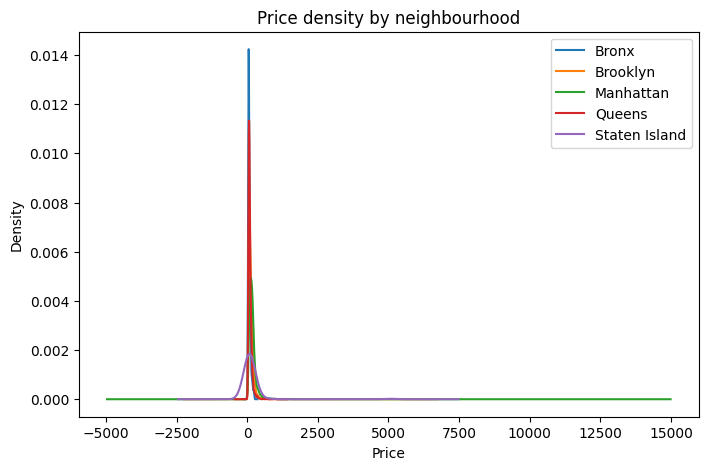

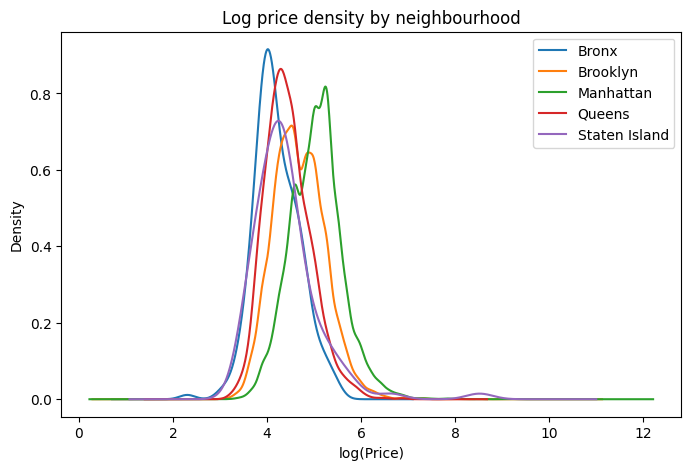

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          4.43e-226
Time:                        22:53:09   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [6]:
# Q2
air = pd.read_csv(DATA_DIR / "Q1_clean.csv").rename(columns={"Neighbourhood ": "Neighbourhood"})

avg_by_neigh = (
    air.groupby("Neighbourhood")[["Price", "Review Scores Rating"]]
    .mean()
    .sort_values("Price", ascending=False)
)
print(avg_by_neigh)

air.groupby("Neighbourhood")["Price"].plot(kind="kde", legend=True, title="Price density by neighbourhood")
plt.xlabel("Price")
plt.show()

air["log_price"] = np.log(air["Price"])
air.groupby("Neighbourhood")["log_price"].plot(kind="kde", legend=True, title="Log price density by neighbourhood")
plt.xlabel("log(Price)")
plt.show()

m_neigh = smf.ols("Price ~ C(Neighbourhood)", data=air).fit()
print(m_neigh.summary())

m_rating = smf.ols('Price ~ Q("Review Scores Rating")', data=air).fit()
print(m_rating.summary())

m_both = smf.ols('Price ~ Q("Review Scores Rating") + C(Neighbourhood)', data=air).fit()
print(m_both.summary())

m_inter = smf.ols('Price ~ Q("Review Scores Rating") * C(Neighbourhood)', data=air).fit()
print(m_inter.summary())

### Q2 short answers

1. Manhattan is the most expensive borough on average, with a mean price of about $183.66 per night. Staten Island is next at about $146.17, then Brooklyn at about $127.75. The Bronx has the lowest average price.

2. In the dummy-variable regression with an intercept, the omitted group is the Bronx. That means the intercept is the Bronx mean, about 75.28. Each reported neighborhood coefficient is that neighborhood's mean minus the Bronx mean:
   - Brooklyn: 52.47
   - Manhattan: 108.39
   - Queens: 21.58
   - Staten Island: 70.89

   So the regression is just another way of writing the group averages. With an intercept included, the omitted category sets the baseline and the dummy coefficients measure departures from that baseline.

3. In the regression of price on review score alone, the slope is about 1.02. On average, a one-point increase in the review score is associated with roughly $1.02 higher nightly price. That is a very small relationship, which matches the low $R^2$.

4. After adding neighborhood controls, the slope on `Review Scores Rating` rises slightly from about 1.02 to about 1.08. The neighborhood differences stay close to the simple mean gaps, but they shift a little because the model is now comparing listings at the same review score rather than averaging over all listings.

5. When I allow each neighborhood to have its own review-score slope by adding interactions, the slopes are not identical. The fitted slopes are:
   - Bronx: about 1.07
   - Brooklyn: about 0.63
   - Manhattan: about 2.12
   - Queens: about 0.48
   - Staten Island: about -2.54

   Most of them are fairly modest, but Manhattan is steeper and Staten Island turns negative. I would be careful about overreading Staten Island because that group is much smaller than the others.

6. Five-fold cross validation gives these average mean squared errors:
   - review score only: 22,079
   - review score + neighborhood: 21,070
   - review score + neighborhood interactions: 21,328

   The model with review score and neighborhood performs best. Adding the interaction terms does not improve prediction here, so the extra complexity does not seem to buy much.

In [7]:
# Cross validation for Q2 models
y = air["Price"]
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

X1 = air[["Review Scores Rating"]]
pipe1 = Pipeline([("model", LinearRegression())])

X2 = air[["Review Scores Rating", "Neighbourhood"]]
pipe2 = Pipeline([
    ("pre", ColumnTransformer(
        [("cat", OneHotEncoder(drop="first"), ["Neighbourhood"])],
        remainder="passthrough"
    )),
    ("model", LinearRegression())
])

X3 = pd.get_dummies(air[["Neighbourhood"]], drop_first=True)
for col in list(X3.columns):
    X3[f"{col}:rating"] = X3[col] * air["Review Scores Rating"]
X3 = pd.concat([air[["Review Scores Rating"]], X3], axis=1)

mse1 = -cross_val_score(pipe1, X1, y, cv=cv5, scoring="neg_mean_squared_error").mean()
mse2 = -cross_val_score(pipe2, X2, y, cv=cv5, scoring="neg_mean_squared_error").mean()
mse3 = -cross_val_score(LinearRegression(), X3, y, cv=cv5, scoring="neg_mean_squared_error").mean()

print("Q2 CV MSEs")
print("Review score only:", mse1)
print("Review score + neighbourhood:", mse2)
print("Review score + neighbourhood interactions:", mse3)

Q2 CV MSEs
Review score only: 22078.787599216383
Review score + neighbourhood: 21070.142285878555
Review score + neighbourhood interactions: 21328.18344590853


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   

                 75%        max  
Body_Type                        
suv        1491250.0  2100000.0  
sedan       968500.0  2941000.0  
crossover   749000.0   883000.0  
muv         738500.0  1091000.0  
hatchback   661000.0  1107000.0

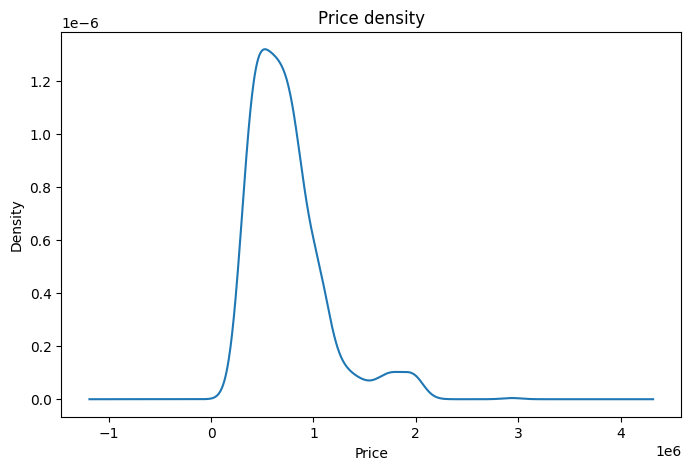

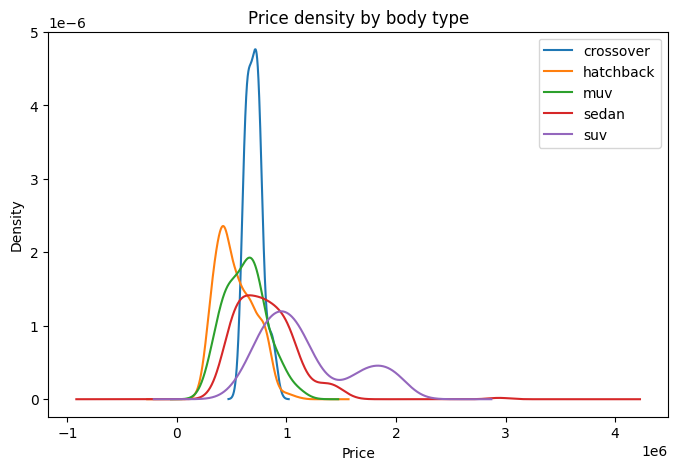

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 20 Apr 2026   Prob (F-statistic):             0.0245
Time:                        22:53:12   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

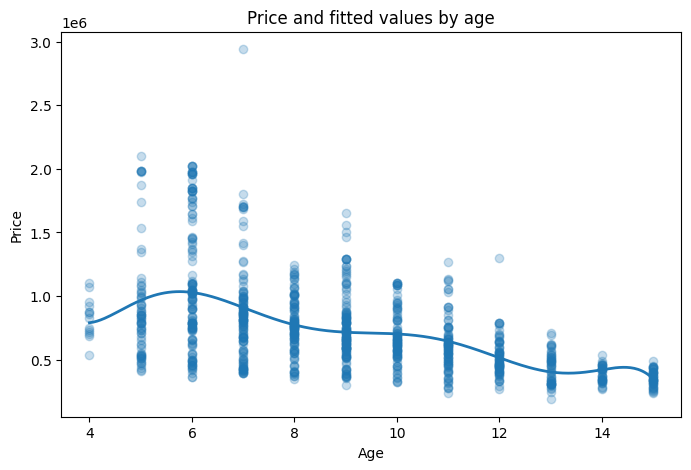

In [8]:
# Q3
cars = pd.read_csv(DATA_DIR / "cars_hw.csv")

print(cars["Price"].describe())
print(cars.groupby("Body_Type")["Price"].describe().sort_values("mean", ascending=False))

cars["Price"].plot(kind="kde", title="Price density")
plt.xlabel("Price")
plt.show()

cars.groupby("Body_Type")["Price"].plot(kind="kde", legend=True, title="Price density by body type")
plt.xlabel("Price")
plt.show()

seat_num = smf.ols("Price ~ Seating_Capacity", data=cars).fit()
seat_cat = smf.ols("Price ~ C(Seating_Capacity)", data=cars).fit()
print(seat_num.summary())
print(seat_cat.summary())

cars["Age"] = 2026 - cars["Make_Year"]

deg_results = []
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)
for d in range(1, 8):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])
    mse = -cross_val_score(pipe, cars[["Age"]], cars["Price"], cv=cv10, scoring="neg_mean_squared_error").mean()
    deg_results.append((d, mse))

deg_df = pd.DataFrame(deg_results, columns=["degree", "cv_mse"])
print(deg_df)

best_degree = deg_df.loc[deg_df["cv_mse"].idxmin(), "degree"]
print("Best degree:", best_degree)

best_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=int(best_degree), include_bias=False)),
    ("model", LinearRegression())
])
best_pipe.fit(cars[["Age"]], cars["Price"])

age_grid = pd.DataFrame({"Age": np.linspace(cars["Age"].min(), cars["Age"].max(), 300)})
age_grid["pred_price"] = best_pipe.predict(age_grid[["Age"]])

plt.scatter(cars["Age"], cars["Price"], alpha=0.25)
plt.plot(age_grid["Age"], age_grid["pred_price"], linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price and fitted values by age")
plt.show()

### Q3 short answers

1. The average car price is about 741,020 rupees, with a median of 666,500 rupees. SUVs are the most expensive body type on average at about 1,176,495 rupees, followed by sedans. SUVs also have the largest standard deviation, so they show the most variation in price. Hatchbacks are the cheapest and are much more tightly clustered.

2. In the numeric regression, the slope on seating capacity is about 59,268. That means one additional seat is associated with roughly 59 thousand more rupees in price on average. When seating capacity is treated as categorical, the pattern is not cleanly linear. The estimate is dominated by five-seat cars because almost the entire sample falls in that category, while 4, 6, and 8 seats are barely represented. So the category model suggests that larger vehicles do tend to cost more, but the relationship is not smooth enough to call it strongly linear.

3. I created `Age = 2026 - Make_Year` and compared polynomial models from degree 1 through degree 7 using 10-fold cross validation. The lowest cross-validated mean squared error occurs at degree 7, so among the models tested, the seventh-degree polynomial fits best out of sample.

4. The fitted curve captures the broad idea that older cars tend to be cheaper, but it does not explain all of the spread. Prices vary a lot even among cars of the same age, so age alone leaves out many important factors such as brand, trim, transmission, mileage, and body type.

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 20 Apr 2026   Prob (F-statistic):             0.0133
Time:                        22:53:13   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

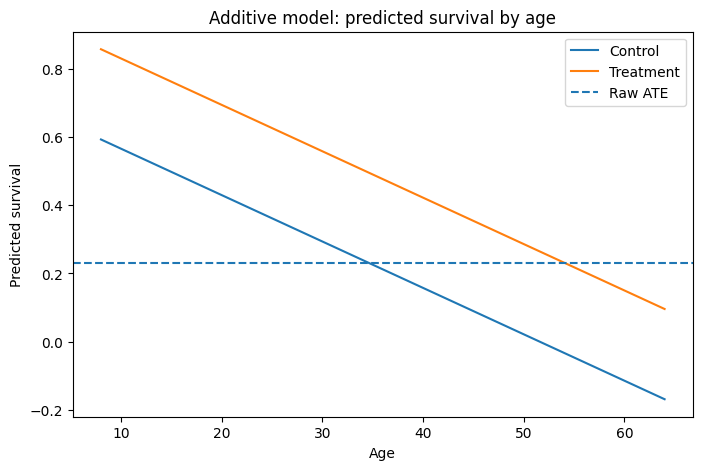

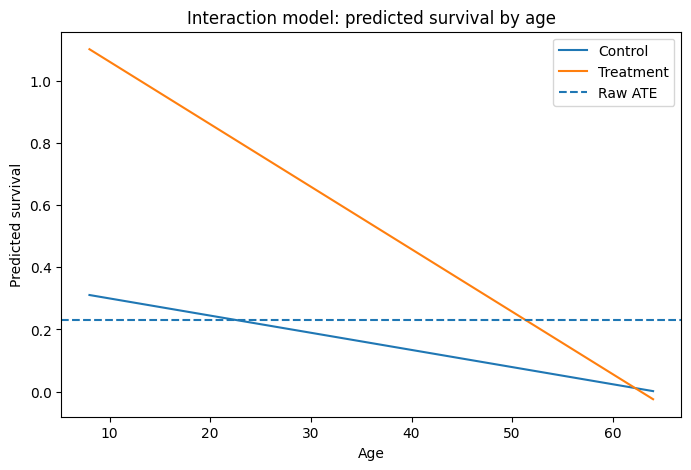

Q4 CV MSEs
Treatment only: 0.1930687841733136
Treatment + age: 0.17726651658550782
Treatment + age + interaction: 0.1751204222198966


In [9]:
# Q4
heart = pd.read_csv(DATA_DIR / "heart_hw.csv")
heart["trt"] = (heart["transplant"] == "treatment").astype(int)

survival = heart.groupby("transplant")["y"].mean()
ate = survival["treatment"] - survival["control"]
print(survival)
print("ATE:", ate)

m_ate = smf.ols("y ~ trt", data=heart).fit()
m_age = smf.ols("y ~ trt + age", data=heart).fit()
m_age_inter = smf.ols("y ~ trt * age", data=heart).fit()

print(m_ate.summary())
print(m_age.summary())
print(m_age_inter.summary())

age_grid = pd.DataFrame({"age": np.linspace(heart["age"].min(), heart["age"].max(), 300)})

age_grid["trt"] = 0
control_pred = m_age.predict(age_grid)
age_grid["trt"] = 1
treat_pred = m_age.predict(age_grid)

plt.plot(age_grid["age"], control_pred, label="Control")
plt.plot(age_grid["age"], treat_pred, label="Treatment")
plt.axhline(ate, linestyle="--", label="Raw ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival")
plt.title("Additive model: predicted survival by age")
plt.legend()
plt.show()

age_grid["trt"] = 0
control_pred_inter = m_age_inter.predict(age_grid)
age_grid["trt"] = 1
treat_pred_inter = m_age_inter.predict(age_grid)

plt.plot(age_grid["age"], control_pred_inter, label="Control")
plt.plot(age_grid["age"], treat_pred_inter, label="Treatment")
plt.axhline(ate, linestyle="--", label="Raw ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival")
plt.title("Interaction model: predicted survival by age")
plt.legend()
plt.show()

cv10 = KFold(n_splits=10, shuffle=True, random_state=42)
X1 = heart[["trt"]]
X2 = heart[["trt", "age"]]
X3 = heart[["trt", "age"]].copy()
X3["trt_age"] = X3["trt"] * X3["age"]

mse1 = -cross_val_score(LinearRegression(), X1, heart["y"], cv=cv10, scoring="neg_mean_squared_error").mean()
mse2 = -cross_val_score(LinearRegression(), X2, heart["y"], cv=cv10, scoring="neg_mean_squared_error").mean()
mse3 = -cross_val_score(LinearRegression(), X3, heart["y"], cv=cv10, scoring="neg_mean_squared_error").mean()

print("Q4 CV MSEs")
print("Treatment only:", mse1)
print("Treatment + age:", mse2)
print("Treatment + age + interaction:", mse3)

### Q4 short answers

1. The three-year survival rate is about 0.1176 in the control group and 0.3478 in the treatment group. The raw average treatment effect is therefore about 0.2302, or 23.0 percentage points.

2. In the regression of `y` on transplant only, the intercept is 0.1176 and the transplant coefficient is 0.2302. Those match the control mean and the treatment-minus-control difference from part 1 exactly.

3. After controlling for age, the transplant coefficient rises to about 0.2647. That suggests the raw difference understated the treatment effect, likely because transplant recipients differ in age from the control group. In this additive model, the treatment effect is constant across ages, so the model says the gain from treatment is 0.2647 for everyone. Since the raw ATE is 0.2302, the raw ATE is underestimating the treatment effect at every age in this specification. The intercept is the predicted survival probability for a control patient at age 0, so it is just a mathematical baseline here and not something with a direct practical meaning. The age slope is about -0.0136, which means predicted survival falls as age rises.

4. Once the interaction term is added, the treatment effect becomes age-dependent. The fitted treatment effect is about `0.9078 - 0.0146*age`, so it gets smaller as age increases. In this model, the transplant effect is larger than the raw ATE for younger patients, smaller than the raw ATE for older patients, and roughly equal around age 46. That changes the story quite a bit because the model no longer assumes one constant benefit for every patient.

5. Ten-fold cross validation gives these mean squared errors:
   - treatment only: 0.1931
   - treatment + age: 0.1773
   - treatment + age + interaction: 0.1751

   The interaction model predicts slightly better than the simpler versions, although the improvement over the additive model is small.

6. I would be cautious about using a model like this to allocate transplant access. The sample is small, the outcome is only three-year survival, and important medical variables are missing. A linear probability model can also produce unrealistic fitted probabilities outside the 0 to 1 range. Beyond the statistics, a deployment decision raises fairness concerns because any bias in the data, diagnosis process, or treatment assignment could be carried into the model and then amplified in a high-stakes setting.